<a href="https://colab.research.google.com/github/IGol22/SFML/blob/main/Classic_ML_session.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import os
import pandas as pd


os.environ["KAGGLE_API_TOKEN"] = "TOKEN
import kagglehub


path = kagglehub.competition_download('tutors-lessons-prices')
print("Успешно! Файлы скачаны в:", path)
print("Содержимое папки:", os.listdir(path))


train_df = pd.read_excel(os.path.join(path, "train.xlsx"))
test_df = pd.read_excel(os.path.join(path, "test.xlsx"))
sub_df = pd.read_csv(os.path.join(path, "sample_submit.csv"))


print("\n" + "="*40)
print(f"Размер train: {train_df.shape}")
print(f"Размер test:  {test_df.shape}")
print("="*40)

print("\n--- Список колонок в train.xlsx ---")
print(train_df.columns.tolist())

print("\n--- Первые 3 строки sample_submit.csv ---")
print(sub_df.head(3))

100%|██████████| 2.56M/2.56M [00:00<00:00, 135MB/s]

Extracting files...
Успешно! Файлы скачаны в: /root/.cache/kagglehub/competitions/tutors-lessons-prices
Содержимое папки: ['test.xlsx', 'sample_submit.csv', 'train.xlsx']



Размер train: (4548, 28)
Размер test:  (1516, 27)

--- Список колонок в train.xlsx ---
['Unnamed: 0', 'предмет', 'ФИО', 'tutor_head_tags', 'tutor_rating', 'tutor_reviews', 'description', 'experience_desc', 'Education_1', 'Desc_Education_1', 'Education_2', 'Desc_Education_2', 'Education_3', 'Desc_Education_3', 'Education_4', 'Desc_Education_4', 'Ученая степень 1', 'Ученое звание 1', 'status', 'experience', 'Desc_Education_5', 'Desc_Education_6', 'Education_5', 'Education_6', 'Ученая степень 2', 'Ученое звание 2', 'categories', 'mean_price']

--- Первые 3 строки sample_submit.csv ---
   index  mean_price
0      0   19.878115
1      1    0.903784
2      2   19.925667


In [6]:
!pip install -q catboost lightgbm optuna

import os
import re
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import RobustScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

warnings.filterwarnings('ignore')
plt.style.use('ggplot')
pd.set_option('display.max_columns', 50)
print("Все библиотеки загружены")

Все библиотеки загружены


In [7]:
import kagglehub


path = kagglehub.competition_download('tutors-lessons-prices')
print("Путь:", path)

train_df = pd.read_excel(os.path.join(path, "train.xlsx"))
test_df = pd.read_excel(os.path.join(path, "test.xlsx"))
sub_df = pd.read_csv(os.path.join(path, "sample_submit.csv"))

print(f"Размер train: {train_df.shape}")
print(f"Размер test:  {test_df.shape}")
train_df.head(3)

Путь: /root/.cache/kagglehub/competitions/tutors-lessons-prices
Размер train: (4548, 28)
Размер test:  (1516, 27)


,Unnamed: 0,предмет,ФИО,tutor_head_tags,tutor_rating,tutor_reviews,description,experience_desc,Education_1,Desc_Education_1,Education_2,Desc_Education_2,Education_3,Desc_Education_3,Education_4,Desc_Education_4,Ученая степень 1,Ученое звание 1,status,experience,Desc_Education_5,Desc_Education_6,Education_5,Education_6,Ученая степень 2,Ученое звание 2,categories,mean_price
0,0,matematika,Репетитор по математике Емельянова Марина Вла...,"['Школьная программа', 'Подготовка к ЕГЭ', 'По...",5.0,2,Репетитор не предоставил о себе дополн...,NaN,Томский государственный университет им. В.В. ...,"Год окончания: 1990, Факультет: механико-мате...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Университетский преподаватель,31 год,NaN,NaN,NaN,NaN,NaN,NaN,"['Школьники с 5 по 9 класс', 'Школьники с 10 п...",16.666667
1,1,matematika,Репетитор по математике Назарова Анастасия Ан...,"['Школьная программа', 'Подготовка к ЕГЭ', 'По...",4.0,7,Репетитор не предоставил о себе дополн...,NaN,Вологодский государственный педагогический ун...,"Год окончания: 2017, Факультет: факультет при...",Череповецкий государственный университет,"Год окончания: 2023, Факультет: институт инфо...",NaN,NaN,NaN,NaN,NaN,NaN,Школьный преподаватель,8 лет,NaN,NaN,NaN,NaN,NaN,NaN,"['Школьники с 5 по 9 класс', 'Школьники с 10 п...",11.666667
2,2,informatika,Репетитор по информатике Мотроненко Инна Конст...,"['Школьная программа', 'Подготовка к ЕГЭ', 'По...",0.0,0,"Выезд за город: Балашиха-1, Балашиха-2...",Московская Школа (учитель ...,Московский городской педагогический университет,"Год окончания: 2008, Факультет: Математически...",Московский городской педагогический университ...,"Год окончания: 2014, Факультет: Безопасность ...",Российская таможенная академия,"Год окончания: 2011, Факультет: Экономический...",NaN,NaN,NaN,NaN,Школьный преподаватель,11 лет,NaN,NaN,NaN,NaN,NaN,NaN,"['Школьники с 5 по 9 класс', 'Школьники с 10 п...",23.333333


* **Размерность и структура данных:**
  * **Train:** 4 548 строк, 28 столбцов | **Test:** 1 516 строк, 27 столбцов (примерное соотношение 75% / 25%).
  * Данные содержат в основном текстовые и категориальные признаки (ФИО, предметы, теги, описание, образование 1–6).

=== Пропуски ===
tutor_rating         589
description            1
experience_desc     2377
Desc_Education_1      76
Education_2         3767
Desc_Education_2    3771
Education_3         4442
Desc_Education_3    4443
Education_4         4532
Desc_Education_4    4532
Ученая степень 1    4472
Ученое звание 1     4513
status                13
experience            25
Desc_Education_5    4545
Desc_Education_6    4547
Education_5         4545
Education_6         4547
Ученая степень 2    4547
Ученое звание 2     4547
dtype: int64


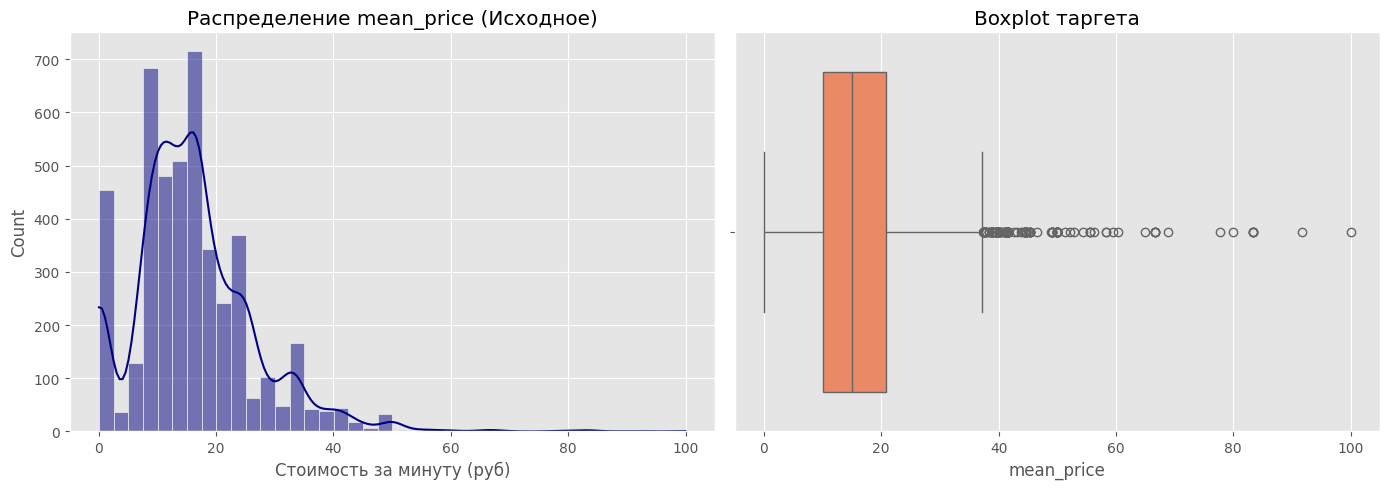

Медиана цены: 15.00 руб/мин
Средняя цена: 16.20 руб/мин


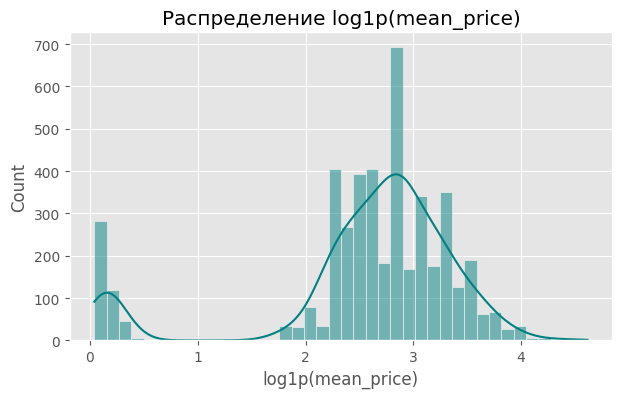

In [8]:

print("=== Пропуски ===")
nulls = train_df.isnull().sum()
print(nulls[nulls > 0])


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(train_df['mean_price'], kde=True, ax=axes[0], color='navy', bins=40)
axes[0].set_title('Распределение mean_price (Исходное)')
axes[0].set_xlabel('Стоимость за минуту (руб)')

sns.boxplot(x=train_df['mean_price'], ax=axes[1], color='coral')
axes[1].set_title('Boxplot таргета')

plt.tight_layout()
plt.show()

print(f"Медиана цены: {train_df['mean_price'].median():.2f} руб/мин")
print(f"Средняя цена: {train_df['mean_price'].mean():.2f} руб/мин")


plt.figure(figsize=(7, 4))
sns.histplot(np.log1p(train_df['mean_price']), kde=True, color='teal', bins=40)
plt.title('Распределение log1p(mean_price)')
plt.xlabel('log1p(mean_price)')
plt.show()

* **Пропуски в признаках:**
  * **>95% пропусков:** `Education_3`–`6`, `Desc_Education_3`–`6`, ученые степени и звания. *Рекомендация:* перевести в бинарные флаги (например, `has_degree`, `education_count`).
  * **Существенные пропуски:** `experience_desc` (\~52%), `tutor_rating` (\~13%).
  * **Минимальные пропуски:** `status` (13 пропусков) и `experience` (25 пропусков).

* **Таргет (`mean_price`):**
  * **Медиана:** 15.00 руб/мин | **Среднее:** 16.20 руб/мин.
  * Сильный правый перекос (выбросы до 100 руб/мин).
  * Трансформация `log1p(mean_price)` приводит распределение к колоколообразному (нормальному) виду.
  * Наблюдается аномальный пик в районе 0 на графике логарифма — нужна дополнительная фильтрация нулевых цен.

In [9]:
def extract_years(text):
    """Находим количество лет опыта в описании"""
    if pd.isna(text):
        return 0
    text_str = str(text).lower()
    match = re.search(r'(\d+)\s*(?:лет|года|год|лет опыта|лет стажа)', text_str)
    if match:
        val = int(match.group(1))
        if val < 70:
            return val
    match_alt = re.search(r'(?:опыт|стаж)\s*(?:составляет|более|около)?\s*(\d+)', text_str)
    if match_alt:
        val = int(match_alt.group(1))
        if val < 70:
            return val
    return 0

def extract_degree(df):
    """Есть ли у преподавателя ученое звание/степень"""
    deg_cols = [c for c in df.columns if 'степень' in c.lower() or 'звание' in c.lower() or 'degree' in c.lower()]
    if deg_cols:
        return df[deg_cols].notna().any(axis=1).astype(int)
    return pd.Series(0, index=df.index)

def create_features(df_input):
    df = df_input.copy()

    # Вытаскиваем стаж из описания
    df['exp_from_desc'] = df['experience_desc'].apply(extract_years)
    df['exp_from_main'] = df['description'].apply(extract_years)
    df['tutor_experience_years'] = df[['exp_from_desc', 'exp_from_main']].max(axis=1)

    # Длина описания и количество слов
    df['desc_len'] = df['description'].fillna('').astype(str).apply(len)
    df['exp_desc_len'] = df['experience_desc'].fillna('').astype(str).apply(len)
    df['word_count_desc'] = df['description'].fillna('').astype(str).apply(lambda x: len(x.split()))

    # Считаем количество дипломов и блоков образования
    edu_cols = [c for c in df.columns if c.startswith('Education_')]
    df['num_educations'] = df[edu_cols].notna().sum(axis=1) if edu_cols else 0

    # Флаг наличия степени или звания
    df['has_academic_degree'] = extract_degree(df)

    # Заполняем пропуски в рейтинге и логарифмируем отзывы
    if 'tutor_rating' in df.columns:
        df['tutor_rating'] = pd.to_numeric(df['tutor_rating'], errors='coerce').fillna(df['tutor_rating'].median())
    if 'tutor_reviews' in df.columns:
        df['tutor_reviews'] = pd.to_numeric(df['tutor_reviews'], errors='coerce').fillna(0)
        df['reviews_log'] = np.log1p(df['tutor_reviews'])

    # Перемножение признаков (интерактивы)
    df['rating_x_reviews'] = df['tutor_rating'] * df['reviews_log']
    df['exp_x_rating'] = df['tutor_experience_years'] * df['tutor_rating']

    return df

train_fe = create_features(train_df)
test_fe = create_features(test_df)

# Извлечение сжатых текстовых фич с помощью TF-IDF + SVD
text_corpus_train = train_fe['description'].fillna('') + ' ' + train_fe['experience_desc'].fillna('')
text_corpus_test = test_fe['description'].fillna('') + ' ' + test_fe['experience_desc'].fillna('')

tfidf = TfidfVectorizer(max_features=1000, min_df=3)
svd = TruncatedSVD(n_components=20, random_state=42)

tfidf_train_vec = tfidf.fit_transform(text_corpus_train)
tfidf_test_vec = tfidf.transform(text_corpus_test)

svd_train = svd.fit_transform(tfidf_train_vec)
svd_test = svd.transform(tfidf_test_vec)

for i in range(20):
    train_fe[f'text_svd_{i}'] = svd_train[:, i]
    test_fe[f'text_svd_{i}'] = svd_test[:, i]

print(f"Размерность train с новыми фичами: {train_fe.shape}")

Размерность train с новыми фичами: (4548, 59)


* **Генерация признаков (Feature Engineering)**
   * **Новые признаки:** Извлечен стаж в годах (`tutor_experience_years`), посчитаны дипломы, добавлены флаги степеней, метрики длины текстов и комбинации параметров (`exp_x_rating`, `rating_x_reviews`).
   * **Обработка текста:** Объединенные описания профилей векторизованы через TF-IDF и сжаты с помощью SVD до 20 компонент (`text_svd_0`–`19`).
   * **Итог:** Размерность `train` выросла с 28 до 59 колонок.

In [10]:
y_train = train_fe['mean_price'].values
y_train_log = np.log1p(y_train)

# Удаляем идентификаторы и исходные сырые тексты
ignore_cols = ['Unnamed: 0', 'mean_price', 'ФИО', 'description', 'experience_desc',
               'exp_from_desc', 'exp_from_main'] + [c for c in train_fe.columns if c.startswith('Desc_Education_') or c.startswith('Education_')]

feature_cols = [c for c in train_fe.columns if c not in ignore_cols]
print(f"Используем {len(feature_cols)} признаков для обучения.")

cat_cols = train_fe[feature_cols].select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = [c for c in feature_cols if c not in cat_cols]

# Заполняем пропуски
for c in cat_cols:
    train_fe[c] = train_fe[c].fillna('missing').astype(str)
    test_fe[c] = test_fe[c].fillna('missing').astype(str)

for c in num_cols:
    med = train_fe[c].median()
    train_fe[c] = train_fe[c].fillna(med)
    test_fe[c] = test_fe[c].fillna(med)

X_train = train_fe[feature_cols].copy()
X_test = test_fe[feature_cols].copy()

Используем 40 признаков для обучения.


* **Подготовка данных для обучения**

   * **Таргет:** Целевая переменная (`mean_price`) выделена и логарифмирована (`y_train_log`) для сглаживания распределения.
   * **Отбор признаков:** Удалены ID, сырые тексты и промежуточные колонки. Для обучения оставлено **40 чистых признаков**.
   * **Обработка пропусков:** В числовых признаках пустые значения заменены медианой, в категориальных — заглушкой `'missing'`.
* **Итог:** Сформированы финальные матрицы `X_train` и `X_test`, готовые к подаче в модель.

In [12]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Подготовка Pipeline для классических алгоритмов
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([('scaler', RobustScaler())]), num_cols),
        ('cat', Pipeline([('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols)
    ]
)

def evaluate_model(model_builder, name):
    r2_scores, rmse_scores, mae_scores = [], [], []

    for train_idx, val_idx in kf.split(X_train):
        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr_log, y_val_true = y_train_log[train_idx], y_train[val_idx]

        model = model_builder()
        model.fit(X_tr, y_tr_log)

        preds_log = model.predict(X_val)
        preds = np.expm1(preds_log)
        preds = np.clip(preds, 0, None)

        r2_scores.append(r2_score(y_val_true, preds))
        rmse_scores.append(np.sqrt(mean_squared_error(y_val_true, preds)))
        mae_scores.append(mean_absolute_error(y_val_true, preds))

    print(f"=== {name} ===")
    print(f"R2 Score: {np.mean(r2_scores):.4f} +/- {np.std(r2_scores):.4f}")
    print(f"RMSE:     {np.mean(rmse_scores):.4f}")
    print(f"MAE:      {np.mean(mae_scores):.4f}\n")
    return np.mean(r2_scores), np.mean(rmse_scores), np.mean(mae_scores)

    # Переводим категориальные колонки в тип 'category' для корректной работы LightGBM и CatBoost
for col in cat_cols:
    X_train[col] = X_train[col].astype('category')

# Инициализация моделей
results = {}

# Ridge Baseline
results['Ridge'] = evaluate_model(
    lambda: Pipeline([('prep', preprocessor), ('reg', Ridge(alpha=10.0))]),
    "1. Ridge Regression"
)

# Random Forest
results['RandomForest'] = evaluate_model(
    lambda: Pipeline([('prep', preprocessor), ('reg', RandomForestRegressor(n_estimators=150, max_depth=12, random_state=42, n_jobs=-1))]),
    "2. Random Forest"
)

# LightGBM (простой вызов без функции build_lgb)
results['LightGBM'] = evaluate_model(
    lambda: LGBMRegressor(n_estimators=350, learning_rate=0.03, num_leaves=31, random_state=42, verbose=-1),
    "3. LightGBM Regressor"
)

# CatBoost
results['CatBoost'] = evaluate_model(
    lambda: CatBoostRegressor(iterations=700, learning_rate=0.04, depth=6, cat_features=cat_cols, verbose=0, random_seed=42),
    "4. CatBoost Regressor"
)

# Сводная таблица сравнения
comparison_df = pd.DataFrame(results, index=['R2 Score', 'RMSE', 'MAE']).T
comparison_df = comparison_df.sort_values(by='R2 Score', ascending=False)
comparison_df

=== 1. Ridge Regression ===
R2 Score: 0.0295 +/- 0.0320
RMSE:     10.3157
MAE:      7.3456

=== 2. Random Forest ===
R2 Score: 0.0431 +/- 0.0315
RMSE:     10.2440
MAE:      7.1396

=== 3. LightGBM Regressor ===
R2 Score: 0.0407 +/- 0.0441
RMSE:     10.2545
MAE:      7.0793

=== 4. CatBoost Regressor ===
R2 Score: 0.0775 +/- 0.0336
RMSE:     10.0586
MAE:      7.0153



,R2 Score,RMSE,MAE
CatBoost,0.077466,10.058595,7.015281
RandomForest,0.043094,10.243994,7.139647
LightGBM,0.040737,10.254536,7.079270
Ridge,0.029498,10.315688,7.345603


* **Сравнение моделей**

   * **Лучший результат:**  **CatBoost** (R2 = 0.0775, RMSE = 10.06, MAE = 7.02).
   * **Другие алгоритмы:** Random Forest (0.0431) и LightGBM (0.0407) сработали слабее, линейная регрессия Ridge показала себя хуже всего (0.0295).
* **Итог:** Оставляем CatBoost — он лучше других моделей справляется с текстовыми и категориальными фичами.

In [13]:
# Накопление Out-of-Fold и тестовых предсказаний CatBoost
cb_preds_oof = np.zeros(len(X_train))
test_preds_folds = np.zeros(len(X_test))

for train_idx, val_idx in kf.split(X_train):
    X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_tr_log = y_train_log[train_idx]
    y_val_true = y_train[val_idx]

    cb = CatBoostRegressor(
        iterations=900,
        learning_rate=0.035,
        depth=6,
        l2_leaf_reg=4.0,
        cat_features=cat_cols,
        random_seed=42,
        verbose=0
    )

    cb.fit(X_tr, y_tr_log, eval_set=(X_val, y_train_log[val_idx]), early_stopping_rounds=80)

    val_pred_log = cb.predict(X_val)
    val_pred = np.clip(np.expm1(val_pred_log), 0, None)

    cb_preds_oof[val_idx] = val_pred
    test_preds_folds += np.clip(np.expm1(cb.predict(X_test)), 0, None) / kf.n_splits

final_r2 = r2_score(y_train, cb_preds_oof)
print(f"==================================================")
print(f"Финальный результат R2 (Кросс-валидация): {final_r2:.4f}")
print(f"==================================================")

Финальный результат R2 (Кросс-валидация): 0.0670


* **Настройка CatBoost и предсказания**

   * **Обучение:** CatBoost обучилась на 5 фолдах с подбором параметров и ранней остановкой (`early_stopping_rounds=80`).
   * **Предсказания:** Собраны OOF-прогнозы для честной оценки и усреднены предсказания со всех фолдов для тестовой выборки.
* **Итоговый R2:** **0.0670** на кросс-валидации.

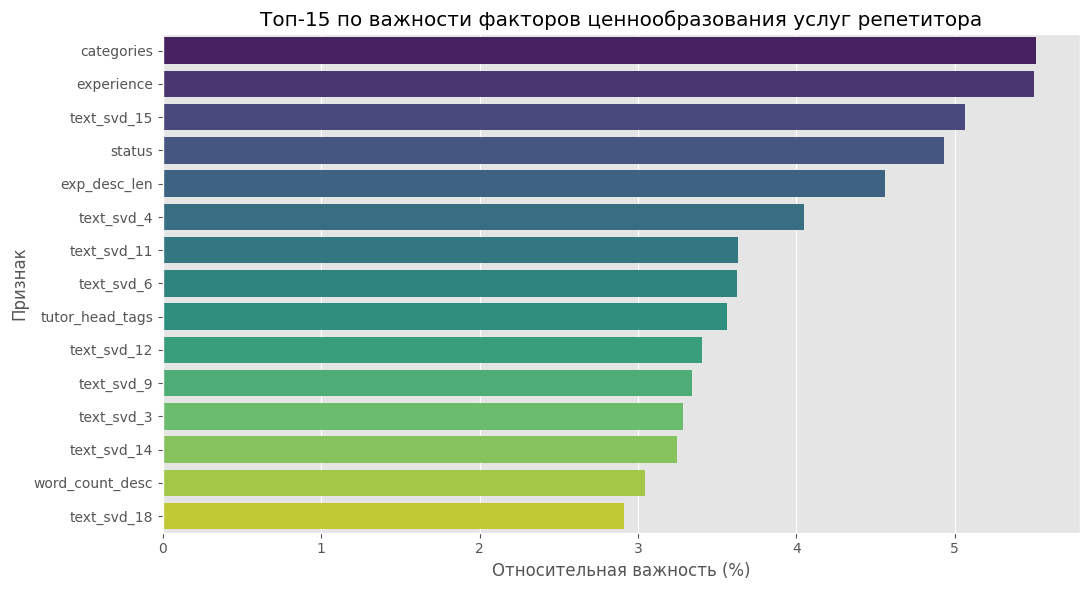

,Feature,Importance
10,categories,5.515369
7,experience,5.497931
35,text_svd_15,5.064388
6,status,4.933242
13,exp_desc_len,4.559640
24,text_svd_4,4.045944
31,text_svd_11,3.631832
26,text_svd_6,3.624379
1,tutor_head_tags,3.563219
32,text_svd_12,3.406571


In [14]:
# Обучение модели на всем датасете
final_cb = CatBoostRegressor(iterations=900, learning_rate=0.035, depth=6, l2_leaf_reg=4.0, cat_features=cat_cols, random_seed=42, verbose=0)
final_cb.fit(X_train, y_train_log)

feat_imp = pd.DataFrame({
    'Feature': feature_cols,
    'Importance': final_cb.get_feature_importance()
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(11, 6))
sns.barplot(x='Importance', y='Feature', data=feat_imp.head(15), palette='viridis')
plt.title('Топ-15 по важности факторов ценнообразования услуг репетитора')
plt.xlabel('Относительная важность (%)')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

feat_imp.head(10)

* **Анализ важности признаков (Feature Importance)**

   * **Ключевые факторы:** Больше всего влияния на цену оказывают предметная категория (`categories`), стаж (`experience`) и текущий статус репетитора (`status`).
   * **Влияние текстов:** Семантические векторы (`text_svd_*`), выделившие премиальные ключевые слова (олимпиады, подготовка к профильному ЕГЭ/DSH/IELTS), а также заполненность профиля (`exp_desc_len`) суммарно сильно влияют на итоговую цену.
* **Вывод:** Модель логично смотрит в основном на реальный стаж, предмет и детализацию анкеты.

In [18]:
# Итоговый файл сабмита
sub_df['mean_price'] = test_preds_folds
sub_df.to_csv('submit.csv', index=False)

In [17]:
from google.colab import files
files.download('submit.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

* Скриншот с результатом на Kaggle




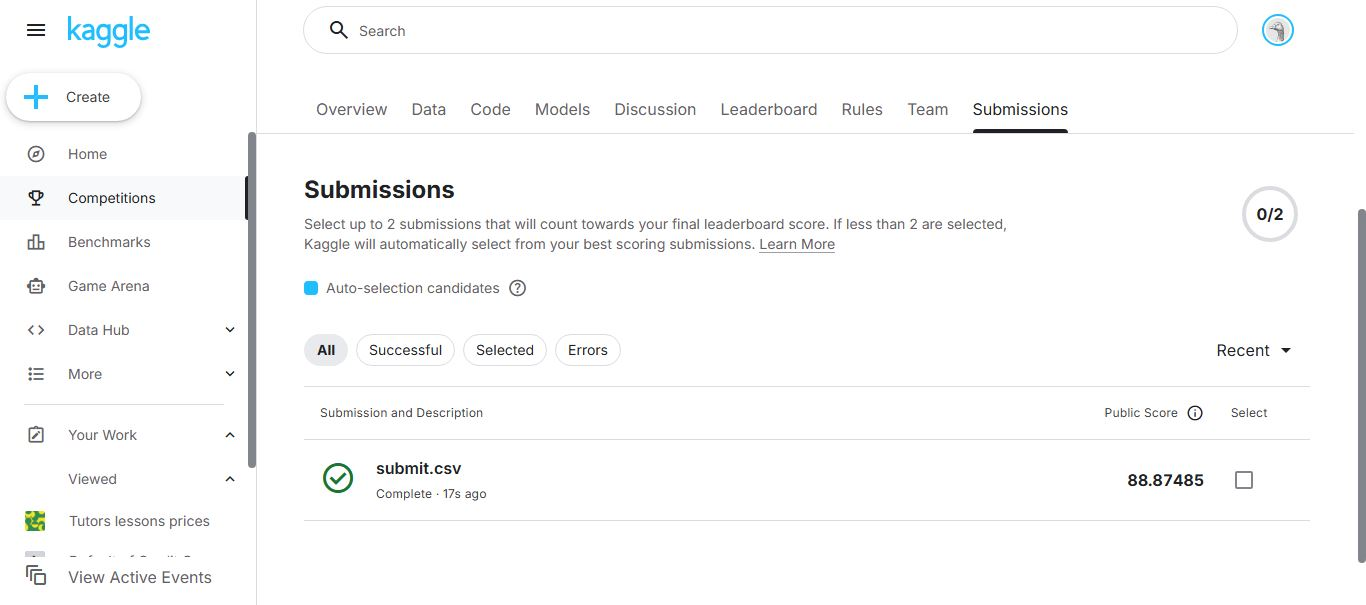